In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import r2_score, mean_squared_error, classification_report

# Sınıflandırma metrikleri (Logistic Regression, Decision Tree, Random Forest için)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Multicollinearity kontrolü (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('income_evaluation.csv')
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [4]:
df.info()
# 15 columns
# 32561 rows
# non-null 

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              32561 non-null  int64
 1    workclass       32561 non-null  str  
 2    fnlwgt          32561 non-null  int64
 3    education       32561 non-null  str  
 4    education-num   32561 non-null  int64
 5    marital-status  32561 non-null  str  
 6    occupation      32561 non-null  str  
 7    relationship    32561 non-null  str  
 8    race            32561 non-null  str  
 9    sex             32561 non-null  str  
 10   capital-gain    32561 non-null  int64
 11   capital-loss    32561 non-null  int64
 12   hours-per-week  32561 non-null  int64
 13   native-country  32561 non-null  str  
 14   income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


### Data cleaning

In [5]:
df.columns = df.columns.str.strip()
df['workclass'] = df['workclass'].str.strip()
df['income'] = df['income'].str.strip()
# State-gov, <=50K


In [10]:
df.sample(n=10)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32545,39,Local-gov,12,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,1
13040,28,Private,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,1
31965,37,Private,9,Divorced,Other-service,Unmarried,Black,Female,0,0,30,United-States,0
22504,41,Private,9,Divorced,Transport-moving,Unmarried,White,Male,7443,0,40,United-States,0
17949,28,State-gov,10,Separated,Exec-managerial,Own-child,White,Male,0,2339,40,United-States,0
20622,32,Private,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,Germany,0
9560,42,Local-gov,10,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,0
816,41,Private,11,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,60,United-States,0
16825,38,Private,9,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,0
30386,21,Private,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,0


In [ ]:
# for col in df.select_dtypes(include='object').columns:
#     print(col, "->", df[col].str.strip().unique())
#     print()

# native country occupation work_country

In [ ]:
# mask = df.apply(lambda row: row.astype(str).str.strip().eq('?').any(), axis=1)
# df[mask]

In [7]:
# önce boşlukları temizle
obj_cols = df.select_dtypes(include=['object', 'str']).columns
df[obj_cols] = df[obj_cols].apply(lambda x: x.str.strip())

# ? işaretlerini NaN yap
df[obj_cols] = df[obj_cols].replace('?', np.nan)

# workclass ve occupation'da ? olan satırları drop et
df = df.dropna(subset=['workclass', 'occupation'])

# native-country nan values to usa
df['native-country'] = df['native-country'].fillna('United-States')

In [9]:
# Income column to boolean values
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# dropping non usable, related columns
df = df.drop(columns=['fnlwgt', 'education'])

## Modeling

In [19]:
X = df.drop(columns=['income'])
y = df['income']

# columns to numbers before modeling
X = pd.get_dummies(X, drop_first=True)
# X.shape

####
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
####


# stratify reason is our y data imbalance approx 75-25 percent.
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, stratify=y, test_size=0.2 )

log_reg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42, solver='liblinear')
log_reg.fit(X_train,y_train)


y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7740885416666666

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.75      0.83      4614
           1       0.53      0.85      0.65      1530

    accuracy                           0.77      6144
   macro avg       0.73      0.80      0.74      6144
weighted avg       0.83      0.77      0.79      6144


Confusion Matrix:
 [[3462 1152]
 [ 236 1294]]


### Decision Tree

In [20]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)
dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

# for overfitting
print("Train Accuracy:", dt.score(X_train, y_train))
print("Test Accuracy:", dt.score(X_test, y_test))

Accuracy: 0.80517578125

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.78      0.86      4614
           1       0.57      0.88      0.69      1530

    accuracy                           0.81      6144
   macro avg       0.76      0.83      0.77      6144
weighted avg       0.86      0.81      0.82      6144


Confusion Matrix:
 [[3607 1007]
 [ 190 1340]]
Train Accuracy: 0.8171237893708798
Test Accuracy: 0.80517578125


### Random Tree

In [21]:
rf = RandomForestClassifier( 
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42)

rf.fit(X_train,y_train)

y_pred_dt = rf.predict(X_test)

In [22]:
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Accuracy: 0.81396484375

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.79      0.86      4614
           1       0.58      0.88      0.70      1530

    accuracy                           0.81      6144
   macro avg       0.77      0.84      0.78      6144
weighted avg       0.86      0.81      0.82      6144


Confusion Matrix:
 [[3653  961]
 [ 182 1348]]
Train Accuracy: 0.8339708635142834
Test Accuracy: 0.81396484375


In [23]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

marital-status_Married-civ-spouse    0.178513
education-num                        0.117538
age                                  0.110064
capital-gain                         0.100202
marital-status_Never-married         0.093687
hours-per-week                       0.061013
sex_Male                             0.039899
relationship_Not-in-family           0.036082
relationship_Own-child               0.033816
capital-loss                         0.026972
dtype: float64


### Plots

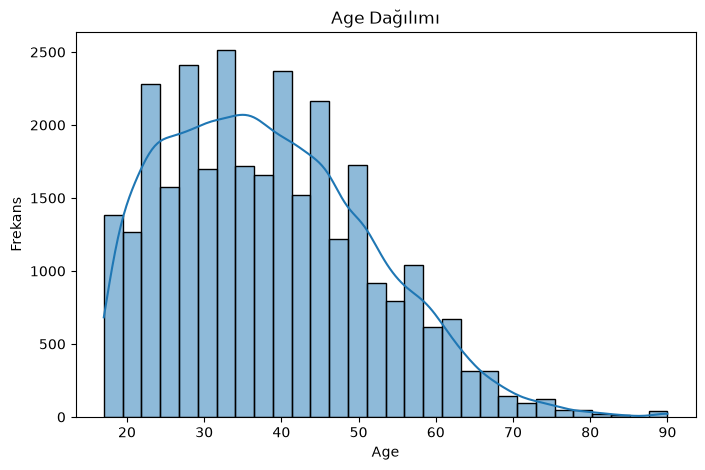

In [24]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Dağılımı')
plt.xlabel('Age')
plt.ylabel('Frekans')
plt.show()

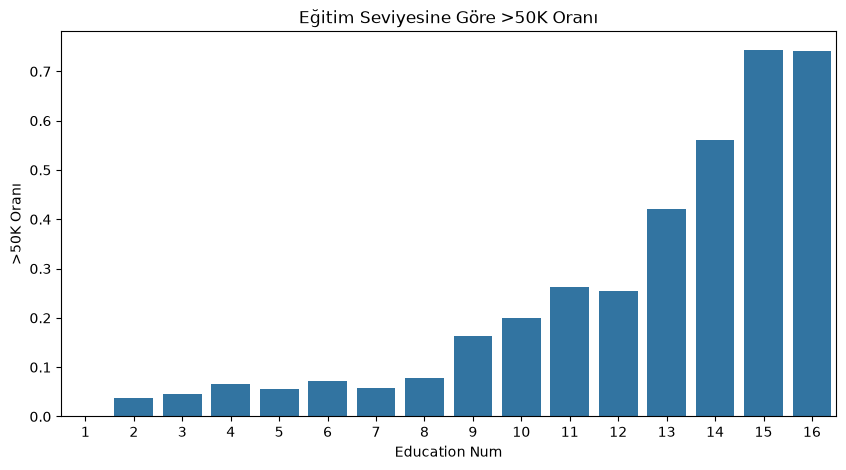

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(x='education-num', y='income', data=df, errorbar=None)
plt.title('Eğitim Seviyesine Göre >50K Oranı')
plt.xlabel('Education Num')
plt.ylabel('>50K Oranı')
plt.show()

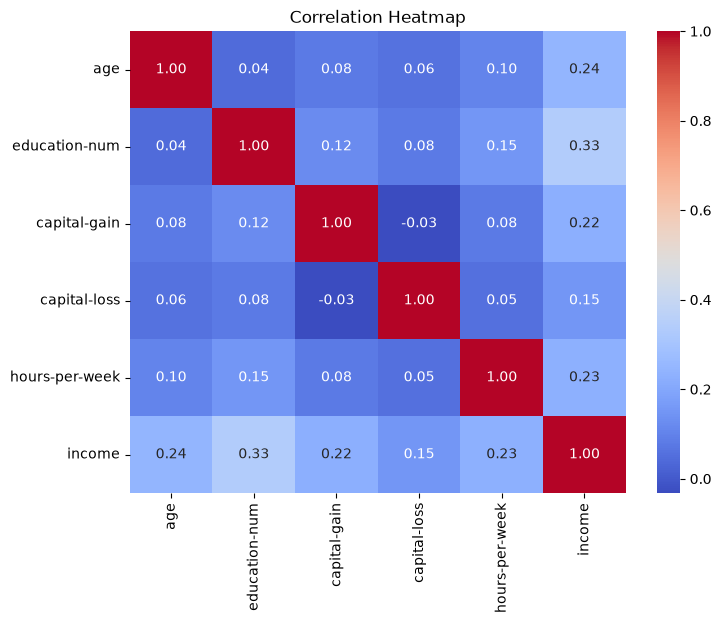

In [26]:
plt.figure(figsize=(8,6))
numeric_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

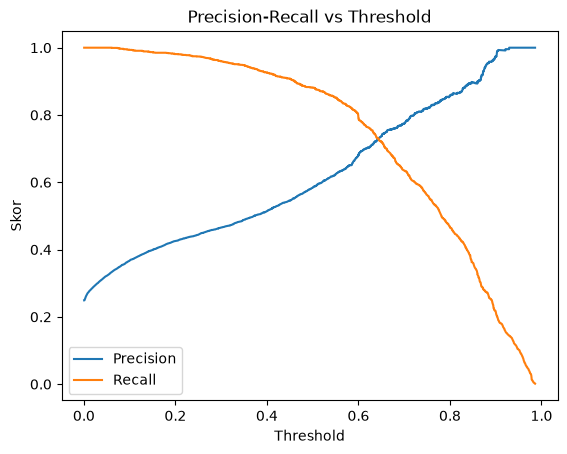

In [28]:
from sklearn.metrics import precision_recall_curve

y_proba = rf.predict_proba(X_test)[:, 1]

custom_threshold = 0.3
y_pred_custom = (y_proba >= custom_threshold).astype(int)


precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Skor')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()